# Prueba del flujo de artifacts N-BEATS


Este notebook valida el flujo de entrenamiento y pronostico agregado al paquete: carga `AT.csv`, selecciona un bloque de entrenamiento, entrena un modelo N-BEATS con horizonte 24 e `input_size` 168, guarda el modelo entrenado, genera un pronostico desde un contexto posterior y revisa los archivos CSV/JSON producidos como artifacts.

Importamos las dependencias necesarias y agregamos `src/` al `sys.path` para que el notebook pueda usar el paquete local aunque se ejecute directamente desde la carpeta `notebooks/`.

In [43]:
from pathlib import Path
import warnings
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

warnings.filterwarnings("ignore", message=".*isinstance\\(treespec.*")

from energy_forecast.services import (
    generate_nbeats_forecast,
    select_training_data,
    train_nbeats_model,
)

def display_path(path: Path) -> str:
    return str(Path(path).resolve().relative_to(PROJECT_ROOT.resolve()))

def display_metadata(payload):
    if isinstance(payload, dict):
        return {key: display_metadata(value) for key, value in payload.items()}
    if isinstance(payload, list):
        return [display_metadata(value) for value in payload]
    if isinstance(payload, str):
        try:
            return display_path(Path(payload))
        except (ValueError, OSError):
            return payload
    return payload

Definimos la configuracion de la prueba. El modelo se entrena con los primeros 1000 registros para que el notebook sea rapido; el horizonte y el `input_size` corresponden a la prueba solicitada.

In [44]:
DATASET_NAME = "AT"
SOURCE_FILE = PROJECT_ROOT / "data" / "processed" / "AT.csv"

HORIZON = 24
FREQ = "h"
INPUT_SIZE = 168
TRAIN_ROWS = 1000
CONTEXT_START_ROW = TRAIN_ROWS
CONTEXT_END_ROW = CONTEXT_START_ROW + INPUT_SIZE

TRAIN_RUN_ID = "notebook_h24_input168"
FORECAST_RUN_ID = "notebook_h24_input168_forecast"

Cargamos el CSV procesado y revisamos su tamano, primeras filas y rango temporal para confirmar que cumple el contrato `timestamp,y`.

In [45]:
df = pd.read_csv(SOURCE_FILE)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

print(f"rows: {len(df):,}")
print(f"start: {df['timestamp'].iloc[0]}")
print(f"end: {df['timestamp'].iloc[-1]}")
df.head()

rows: 50,400
start: 2015-01-01 00:00:00+00:00
end: 2020-09-30 23:00:00+00:00


,timestamp,y
0,2015-01-01 00:00:00+00:00,5946.0
1,2015-01-01 01:00:00+00:00,5726.0
2,2015-01-01 02:00:00+00:00,5347.0
3,2015-01-01 03:00:00+00:00,5249.0
4,2015-01-01 04:00:00+00:00,5309.0


Seleccionamos los datos de entrenamiento y el contexto usado para pronosticar. El contexto tiene exactamente `input_size` filas y termina justo antes del primer timestamp pronosticado.

In [46]:
train_df = select_training_data(df, mode="first_n", first_n=TRAIN_ROWS)
context_df = df.iloc[CONTEXT_START_ROW:CONTEXT_END_ROW].reset_index(drop=True)

print(f"train rows: {len(train_df):,}")
print(f"context rows: {len(context_df):,}")
print(f"last context timestamp: {context_df['timestamp'].iloc[-1]}")

train rows: 1,000
context rows: 168
last context timestamp: 2015-02-18 15:00:00+00:00


Entrenamos N-BEATS con la configuracion definida y guardamos automaticamente el modelo, su configuracion, metadata y el CSV exacto usado como input de entrenamiento.

In [47]:
training = train_nbeats_model(
    app_root=PROJECT_ROOT,
    dataset_name=DATASET_NAME,
    source_file=SOURCE_FILE,
    series=train_df,
    horizon=HORIZON,
    input_size=INPUT_SIZE,
    freq=FREQ,
    model_kwargs={
        "enable_model_summary": False,
        "enable_progress_bar": False,
        "logger": False,
    },
    selection_mode="first_n",
    selection_metadata={"first_n": TRAIN_ROWS},
    run_id=TRAIN_RUN_ID,
    overwrite_model=True,
)

print(display_path(training.model_path))
print(display_path(training.training_input_path))
print(display_path(training.metadata_path))

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
`Trainer.fit` stopped: `max_steps=100` reached.


models/trained/AT/nbeats/h24/notebook_h24_input168
data/training_inputs/AT_nbeats_h24_notebook_h24_input168_train.csv
models/trained/AT/nbeats/h24/notebook_h24_input168/metadata.json


Cargamos el modelo guardado mediante el servicio de pronostico, generamos 24 pasos hacia adelante desde el contexto seleccionado y persistimos el forecast junto con el input usado.

In [48]:
forecast_run = generate_nbeats_forecast(
    app_root=PROJECT_ROOT,
    model_path=training.model_path,
    context=context_df,
    dataset_name=DATASET_NAME,
    run_id=FORECAST_RUN_ID,
)

print(display_path(forecast_run.forecast_path))
print(display_path(forecast_run.forecast_input_path))
print(display_path(forecast_run.metadata_path))
forecast_run.forecast.head()

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


data/forecasts/AT_nbeats_h24_notebook_h24_input168_forecast.csv
data/forecast_inputs/AT_nbeats_h24_notebook_h24_input168_forecast_input.csv
data/forecast_runs/AT_nbeats_h24_notebook_h24_input168_forecast.json


,timestamp,yhat
0,2015-02-18 16:00:00+00:00,9104.419922
1,2015-02-18 17:00:00+00:00,8965.013672
2,2015-02-18 18:00:00+00:00,8824.296875
3,2015-02-18 19:00:00+00:00,8376.189453
4,2015-02-18 20:00:00+00:00,7834.527832


Leemos los archivos JSON generados para comprobar que la configuracion del modelo y la metadata del forecast quedaron trazables.

In [49]:
model_config_path = training.model_path / "config.json"

with model_config_path.open(encoding="utf-8") as file:
    model_config = json.load(file)
with training.metadata_path.open(encoding="utf-8") as file:
    model_metadata = json.load(file)
with forecast_run.metadata_path.open(encoding="utf-8") as file:
    forecast_metadata = json.load(file)

print("model_config:")
print(json.dumps(display_metadata(model_config), indent=2))
print("\nmodel_metadata:")
print(json.dumps(display_metadata(model_metadata), indent=2))
print("\nforecast_metadata:")
print(json.dumps(display_metadata(forecast_metadata), indent=2))

model_config:
{
  "freq": "notebooks/h",
  "horizon": 24,
  "input_size": 168,
  "max_steps": 100,
  "model_kwargs": {
    "enable_model_summary": false,
    "enable_progress_bar": false,
    "logger": false
  }
}

model_metadata:
{
  "dataset": "notebooks/AT",
  "end_timestamp": "notebooks/2015-02-11T15:00:00+00:00",
  "model": "notebooks/nbeats",
  "selection_metadata": {
    "first_n": 1000
  },
  "selection_mode": "notebooks/first_n",
  "source_file": "data/processed/AT.csv",
  "start_timestamp": "notebooks/2015-01-01T00:00:00+00:00",
  "train_rows": 1000,
  "trained_at": "notebooks/2026-05-22T04:28:22.563401+00:00",
  "training_input_path": "data/training_inputs/AT_nbeats_h24_notebook_h24_input168_train.csv"
}

forecast_metadata:
{
  "dataset": "notebooks/AT",
  "first_forecast_timestamp": "notebooks/2015-02-18T16:00:00+00:00",
  "forecast_input_path": "data/forecast_inputs/AT_nbeats_h24_notebook_h24_input168_forecast_input.csv",
  "forecast_path": "data/forecasts/AT_nbeats_h24_no

Graficamos el contexto historico usado como entrada y el pronostico generado para validar visualmente que el forecast empieza despues del ultimo timestamp del input.

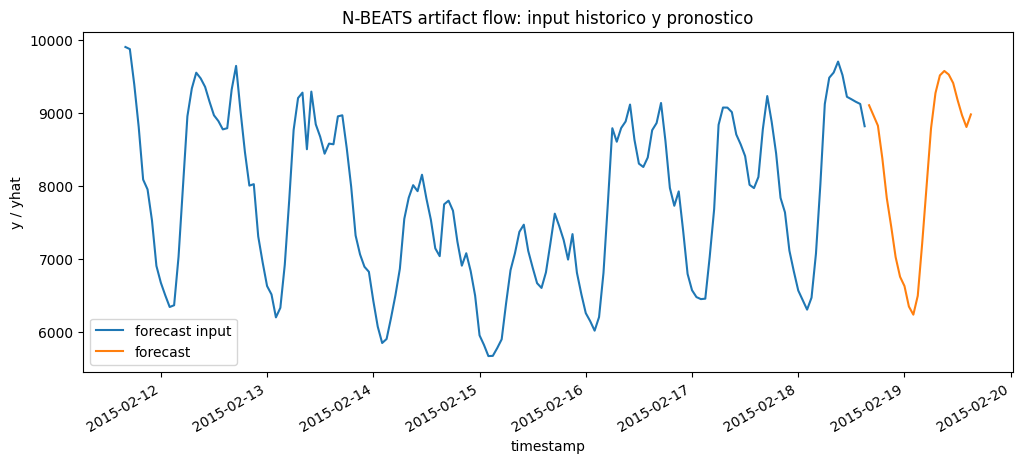

In [50]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(context_df["timestamp"], context_df["y"], label="forecast input")
ax.plot(forecast_run.forecast["timestamp"], forecast_run.forecast["yhat"], label="forecast")
ax.set_title("N-BEATS artifact flow: input historico y pronostico")
ax.set_xlabel("timestamp")
ax.set_ylabel("y / yhat")
ax.legend()
fig.autofmt_xdate()
plt.show()